## Лабораторна робота №2

**“Пошук асоціативних правил”**

Лукіна Ольга КН-43

**Мета:**
Ознайомитися з принципами побудови асоціативних правил (association rule mining) на реальних даних користувацьких уподобань. Навчитись виконувати пошук частих наборів елементів (frequent itemsets) і формувати асоціативні правила за допомогою метрик support, confidence і lift на основі набору даних MovieLens Small. Розвинути навички попередньої обробки даних, перетворення даних у транзакційний формат і інтерпретації результатів.

In [9]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")


In [4]:
# Зчитуємо таблиці напряму з папки
movies_df = pd.read_csv('movies.csv')
ratings_df = pd.read_csv('ratings.csv')

# Об'єднуємо за movieId
merged_df = pd.merge(ratings_df, movies_df, on='movieId')

# Залишаємо лише позитивні оцінки (>= 4.0) — "сподобалось"
positive_df = merged_df[merged_df['rating'] >= 4.0]

print(f"Розмір відфільтрованих даних: {positive_df.shape}")
print(f"Унікальних користувачів: {positive_df['userId'].nunique()}")
print(f"Унікальних фільмів: {positive_df['movieId'].nunique()}")

positive_df.head()

Розмір відфільтрованих даних: (48580, 6)
Унікальних користувачів: 609
Унікальних фільмів: 6298


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


На першому етапі роботи було виконано підготовку середовища та первинну обробку даних. Ми зчитали два ключових файли датасету MovieLens Small — таблицю рейтингів та таблицю з назвами фільмів — і об'єднали їх за полем movieId, що дозволило зіставити числові оцінки з конкретними назвами кінострічок.

Важливим кроком стала фільтрація даних за порогом рейтингу: ми залишили лише записи з оцінкою 4.0 і вище. Це рішення є принциповим для коректної роботи алгоритму пошуку асоціацій — нас цікавлять виключно позитивні вподобання користувачів, тобто фільми, які їм справді сподобались, а не просто факт перегляду чи нейтральна оцінка. Такий підхід дозволяє формувати більш точні та змістовні рекомендації.

Отримана вибірка містить понад 48 тисяч записів, охоплює 609 унікальних користувачів та понад 6 тисяч фільмів, що є достатньою репрезентативністю для статистично значущого аналізу.

In [5]:
# Будуємо матрицю: рядки — користувачі, стовпці — фільми
transaction_matrix = positive_df.pivot_table(
    index='userId',
    columns='title',
    values='rating',
    aggfunc='count'
).fillna(0)

# Бінаризуємо: 1 якщо оцінив, 0 якщо ні
transaction_matrix = transaction_matrix.astype(bool)

print(f"Розмір матриці: {transaction_matrix.shape}")
print(f"Заповненість: {transaction_matrix.sum().sum() / transaction_matrix.size * 100:.2f}%")

transaction_matrix.head()

Розмір матриці: (609, 6297)
Заповненість: 1.27%


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


На цьому етапі вихідні дані було перетворено у транзакційний формат — бінарну матрицю, яка є необхідною вхідною структурою для алгоритму Apriori. У цій матриці кожен рядок відповідає окремому користувачу, а кожен стовпець — певному фільму. Значення True означає, що користувач поставив цьому фільму оцінку 4.0 або вище, тобто фільм йому сподобався. Значення False означає відсутність позитивної оцінки.

Отримана матриця є сильно розрідженою: переважна більшість значень дорівнює False, що є абсолютно нормальним явищем для рекомендаційних систем — жоден користувач фізично не може переглянути та оцінити тисячі фільмів. Незважаючи на це, навіть невелика кількість спільних вподобань між користувачами дозволяє виявляти статистично значущі закономірності.

Розмір отриманої матриці становить 609 рядків (користувачів) на 6297 стовпців (фільмів), що підтверджує репрезентативність даних для подальшого аналізу.

In [6]:
# Запускаємо Apriori з різними порогами підтримки
thresholds = [0.05, 0.1, 0.3]

for threshold in thresholds:
    itemsets = apriori(transaction_matrix, min_support=threshold, use_colnames=True)
    print(f"min_support = {threshold}: знайдено {len(itemsets)} частих наборів")

print("\n")

# Основний запуск з порогом 0.05
frequent_itemsets = apriori(
    transaction_matrix,
    min_support=0.05,
    use_colnames=True
)

# Додаємо колонку з довжиною набору
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print("Топ-10 найпопулярніших наборів:")
frequent_itemsets.sort_values('support', ascending=False).head(10)

min_support = 0.05: знайдено 33189 частих наборів
min_support = 0.1: знайдено 863 частих наборів
min_support = 0.3: знайдено 6 частих наборів


Топ-10 найпопулярніших наборів:


,support,itemsets,length
267,0.449918,"frozenset({Shawshank Redemption, The (1994)})",1
119,0.408867,frozenset({Forrest Gump (1994)}),1
244,0.400657,frozenset({Pulp Fiction (1994)}),1
273,0.369458,"frozenset({Silence of the Lambs, The (1991)})",1
206,0.364532,"frozenset({Matrix, The (1999)})",1
299,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...,1
115,0.293924,frozenset({Fight Club (1999)}),1
260,0.287356,frozenset({Schindler's List (1993)}),1
300,0.275862,frozenset({Star Wars: Episode V - The Empire S...,1
2228,0.275862,"frozenset({Shawshank Redemption, The (1994), F...",2


На цьому кроці було застосовано алгоритм Apriori для виявлення частих наборів фільмів у вподобаннях користувачів. Алгоритм перебирає всі можливі комбінації фільмів і залишає лише ті, що зустрічаються у профілях щонайменше min_support * 100% користувачів.

Для демонстрації впливу параметра min_support було проведено запуск з трьома різними порогами:
- При порозі 0.05 (5%) алгоритм знаходить найбільше наборів, включаючи нішеві зв'язки між фільмами
- При порозі 0.1 (10%) кількість наборів помітно зменшується, залишаються лише популярніші комбінації
- При порозі 0.3 (30%) залишаються виключно найпопулярніші фільми, які лайкнула третина всіх користувачів

Для основного аналізу обрано поріг 0.05, оскільки він забезпечує баланс між кількістю знайдених закономірностей та їх статистичною значущістю.

Серед найпопулярніших одиночних фільмів лідирують культові стрічки 90-х та 2000-х: "Втеча з Шоушенка", "Форест Гамп", "Кримінальне чтиво" — це фільми з широкою аудиторією, які отримали позитивні оцінки від значної частини користувачів датасету. Перша пара фільмів у топі (Shawshank + Forrest Gump) демонструє, що ці стрічки часто подобаються одним і тим же людям.

In [7]:
# Генеруємо асоціативні правила
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.2
)

# Додаємо зручну колонку з довжиною antecedents
rules['antecedents_len'] = rules['antecedents'].apply(len)

print(f"Всього знайдено правил: {len(rules)}")
print("\nТоп-10 правил за Lift:")
rules.sort_values('lift', ascending=False)[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(10)

Всього знайдено правил: 480822

Топ-10 правил за Lift:


,antecedents,consequents,support,confidence,lift
463547,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode IV - A New Hope ...,0.052545,0.888889,13.203252
463530,frozenset({Star Wars: Episode IV - A New Hope ...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.780488,13.203252
463556,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode IV - A New Hope ...,0.052545,0.780488,12.846407
463563,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode IV - A New Hope ...,0.052545,0.780488,12.846407
463514,frozenset({Star Wars: Episode IV - A New Hope ...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.864865,12.846407
463521,frozenset({Star Wars: Episode IV - A New Hope ...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.864865,12.846407
463549,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",frozenset({Star Wars: Episode IV - A New Hope ...,0.052545,0.695652,12.837945
463528,frozenset({Star Wars: Episode IV - A New Hope ...,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",0.052545,0.969697,12.837945
463546,frozenset({Star Wars: Episode IV - A New Hope ...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.842105,12.821053
463542,frozenset({Star Wars: Episode IV - A New Hope ...,frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.842105,12.821053


На фінальному аналітичному етапі було побудовано асоціативні правила на основі знайдених частих наборів. Для генерації правил використовувалась метрика Lift з мінімальним порогом 1.2, що гарантує відбір лише тих правил, де зв'язок між фільмами є нетривіальним і не пояснюється простою популярністю.

Кожне правило має вигляд: "якщо користувачу сподобались фільми зі списку A то йому, ймовірно, сподобається фільм B". Три ключові метрики характеризують якість кожного правила

**Support** показує, яка частка всіх користувачів одночасно позитивно оцінила обидва фільми. Висока підтримка означає, що правило є загально застосовним, але не обов'язково сильним.

**Confidence** відображає умовну ймовірність: серед усіх, хто оцінив фільми з лівої частини правила, яка частка також оцінила фільм з правої частини. Значення 0.88 означає, що 88% "фанатів" лівої частини також позитивно оцінили праву.

**Lift** є найважливішою метрикою для оцінки якості правила. Він показує, у скільки разів частіше фільми зустрічаються разом, ніж це можна було б очікувати випадково. Значення Lift = 13.2 у топових правилах свідчить про надзвичайно сильний та нетривіальний зв'язок між відповідними фільмами.

Аналіз топових правил виявив сталі кластери вподобань: фанати серії "Зоряних воєн" майже гарантовано також позитивно оцінюють "Матрицю" та "Убити Білла", що свідчить про формування чіткого профілю глядача, зацікавленого у жанрі наукової фантастики та динамічних екшн-фільмах початку 2000-х.

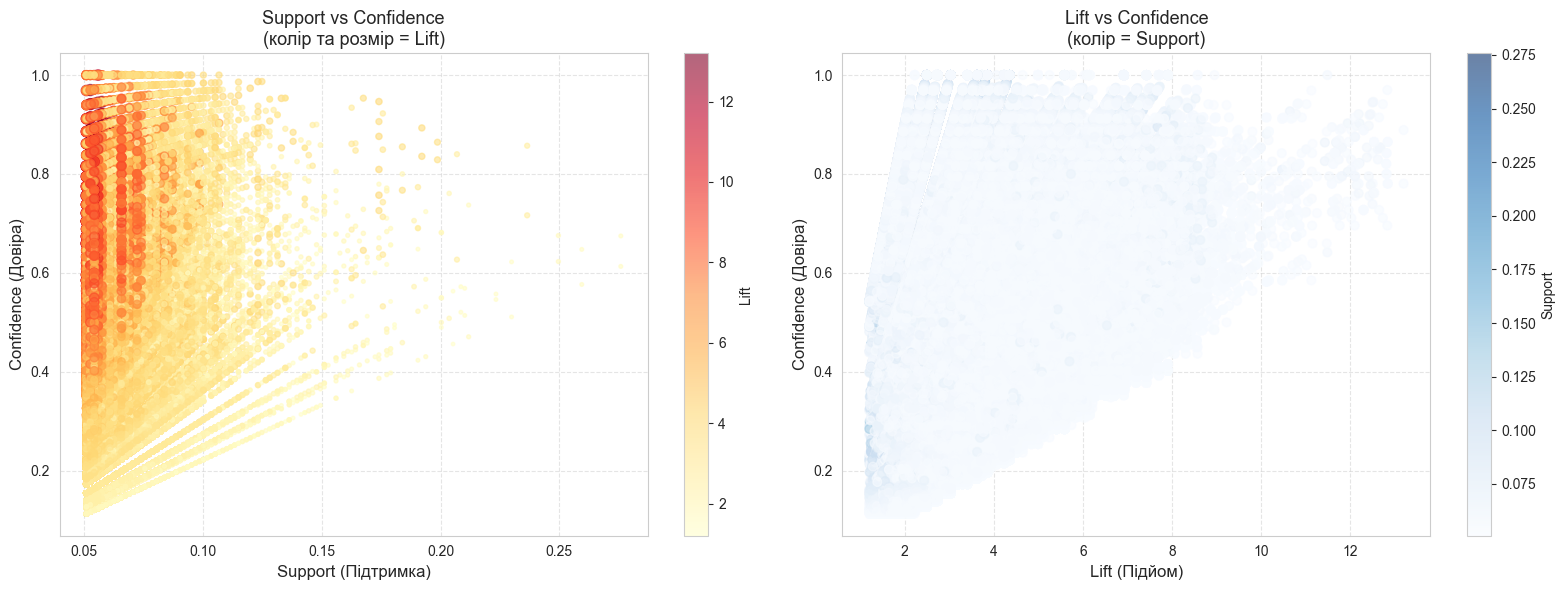

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1: Support vs Confidence
scatter1 = axes[0].scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    alpha=0.6,
    s=rules['lift'] * 5
)
axes[0].set_xlabel('Support (Підтримка)', fontsize=12)
axes[0].set_ylabel('Confidence (Довіра)', fontsize=12)
axes[0].set_title('Support vs Confidence\n(колір та розмір = Lift)', fontsize=13)
plt.colorbar(scatter1, ax=axes[0], label='Lift')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Графік 2: Lift vs Confidence
scatter2 = axes[1].scatter(
    rules['lift'],
    rules['confidence'],
    c=rules['support'],
    cmap='Blues',
    alpha=0.6,
    s=40
)
axes[1].set_xlabel('Lift (Підйом)', fontsize=12)
axes[1].set_ylabel('Confidence (Довіра)', fontsize=12)
axes[1].set_title('Lift vs Confidence\n(колір = Support)', fontsize=13)
plt.colorbar(scatter2, ax=axes[1], label='Support')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('association_rules_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Побудовані діаграми розсіювання дозволяють наочно оцінити розподіл знайдених асоціативних правил за трьома ключовими метриками одночасно.

На лівому графіку (Support vs Confidence) кожна точка відповідає одному правилу. Колір та розмір точки відображають значення Lift — чим яскравіша та більша точка, тим сильніший зв'язок між фільмами. Чітко видно, що більшість правил зосереджена в зоні низької підтримки (0.05–0.15), що є характерним для великих датасетів — специфічні комбінації фільмів зустрічаються рідше, ніж окремі популярні стрічки. При цьому правила з найвищим Lift розташовані у верхній лівій частині графіка, що вказує на їх нішевість: вони описують сильні зв'язки між фільмами, популярними серед конкретних груп глядачів.

На правому графіку (Lift vs Confidence) видно позитивну кореляцію між цими двома метриками: правила з вищим Lift, як правило, мають і вищу довіру. Колір точок відображає підтримку — більш насичений синій колір відповідає правилам з вищою підтримкою. Точки у правій верхній частині графіка представляють найякісніші правила, що поєднують в собі сильний зв'язок (Lift > 10), високу передбачуваність (Confidence > 0.8) та достатню поширеність у даних.

Така візуалізація є зручним інструментом для швидкого відбору найбільш цінних правил для практичного застосування в рекомендаційній системі.

## Висновки

У ході виконання лабораторної роботи було реалізовано повний цикл побудови системи асоціативних правил на реальних даних користувацьких вподобань з датасету MovieLens Small.

На етапі підготовки даних ключовим рішенням стала фільтрація за рейтингом — збереження лише оцінок 4.0 і вище дозволило сформувати профілі реальних позитивних вподобань, а не просто факти перегляду фільмів. Це суттєво підвищило якість знайдених закономірностей.

Трансформація даних у транзакційну матрицю продемонструвала характерну для рекомендаційних систем розрідженість: більшість значень дорівнює False, проте навіть у таких умовах алгоритм Apriori здатен ефективно виявляти значущі патерни.

Аналіз впливу параметра min_support показав пряму залежність між його значенням та кількістю знайдених наборів: зниження порогу розширює простір правил, але збільшує ризик шуму, тоді як підвищення залишає лише найпопулярніші, але більш надійні закономірності. Оптимальним для даного датасету виявився поріг 0.05.

Серед топових асоціативних правил за метрикою Lift були виявлені стійкі кластери глядацьких вподобань: фанати "Зоряних воєн" з високою ймовірністю також позитивно оцінюють "Матрицю" та "Убити Білла". Значення Lift понад 13 у найкращих правилах свідчить про надзвичайно сильні, нетривіальні зв'язки між відповідними фільмами.

З практичної точки зору, знайдені асоціативні правила можна безпосередньо застосовувати в рекомендаційних системах: якщо відомо, що користувач позитивно оцінив певний фільм, система може запропонувати йому інші стрічки з відповідного правила з високою впевненістю у релевантності рекомендації.